<div class="alert alert-block alert-info" >
    <h1>Machine Learning: Assignment 5</h1>
    <h2>This is a three week assignment</h2>
    <h3>General Information:</h3>
    <p>Feel free to add cells if required.<br> Feel free to write your own function block to reduce the redundancy.<br> Answers belong into the corresponding cells (below the question). <br><br> If you encounter empty cells underneath the answer that can not be edited, please ignore them, they are for testing purposes.<br><br>When editing an assignment there can be the case that there are variables in the kernel. To make sure your assignment works, please restart the kernel and run all cells before submitting (e.g. via <i>Kernel -> Restart & Run All</i>). We don't consider that respective solution if you make this mistake (no excuse).</p>
    <br><br><b> Plot should have axis labels, grid, legend, title, atleast size 10X10 also give proper comments, function name, variable names to your coding, if you didn't follow the instructions there will be a reduction in the points.</b><br><br>
     <br><br><b> Write sudo-code if you didn't get output or left out of time so that you will be awarded with atmost 50% of marks for that particular session.</b><br><br>
    <h3>Submission:</h3>
    <p>Use the following naming convention for your submissions: LA_FirstnameLastname_dateOfLecture, e.g LA_JohnDoe_YYMMDD
     <br><br>Please submit your notebook via LEA. The assignment is due on <b>$10^{th}$ January, Sunday at 12:00.</b> </p>
    <h3>Group Work:</h3>
    <p>You are allowed to work in groups of up to two people. Please enter the UID (your username here) of each member of the group into the next cell. We apply plagiarism checking, so do not submit solutions from other people except your team members. If an assignment has a copied solution, the task will be graded with 0 points for all people with the same solution.</p>
    <p><b>YOU SHOULD ONLY SUBMIT EXACTLY ONE PER GROUP</b></p>
    <h3>Questions about the Assignment:</h3>
    <p>If you have questions about the assignment please post them in the LEA forum before the deadline. Don't wait until the last day to post questions.</p></div>

In [ ]:
'''
Group Work:
Enter the UID (i.e. student2s) of each team member into the variables.
If you work alone please leave the second variable empty, or extend the list if necessary.
'''
member1 = 'g_vrammo2s'
member2 = ''

# Ensembles  [100 points]

###  Consider 'house_data.csv' dataset which includes homes sold between 06.2014 and 05.2015. Your task is to use AdaBoost  and Random Forest algorithms to predict the sales price of houses. "Price" is the label

#### Note:- You don't need to watch the Lecture slide 7, 8, 9 to solve this but to understand whats happening you should go through it.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import sklearn

#Added libraries
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import explained_variance_score, make_scorer
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, max_error
import time
from sklearn import linear_model
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
from sklearn.model_selection import KFold
import missingno as msno

## Task 1: Preprocessing [35 points]

### 1. Load the data and display. Below the code cell write the adaboost algorithm (Just the 4 steps, no need explanation)[5 points]

In [ ]:
data = pd.read_csv('house_data.csv')
df = pd.DataFrame(data)
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


Adaboost Algorithm:
<br>
Step 1: Initialize sample weight = 1/N for all datapoints.
<br>
Step 2: Iterate over m to train a weak learner (classifier) using weights to minimize weighted error and then estimate.
<br>
Step 3: Calculate weighting coefficients of weak classifier.
<br>
Step 4: Update weighting coefficients

### 2. Print or visualise the following [15 points]
- What is the size of the data.
- What is the datatype of each feature/column.
- Null or missing values.  
- What are unique values of categorical variables

In [ ]:
# !pip install missingno



Size of Data
 453873 

Feature Data Types 
 id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object 

Null values 
 [[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]] AxesSubplot(0.125,0.125;0.698618x0.755) 

Unique Category Values         0      1
0   15339  14466
1     164    220
2     349   2091
3 

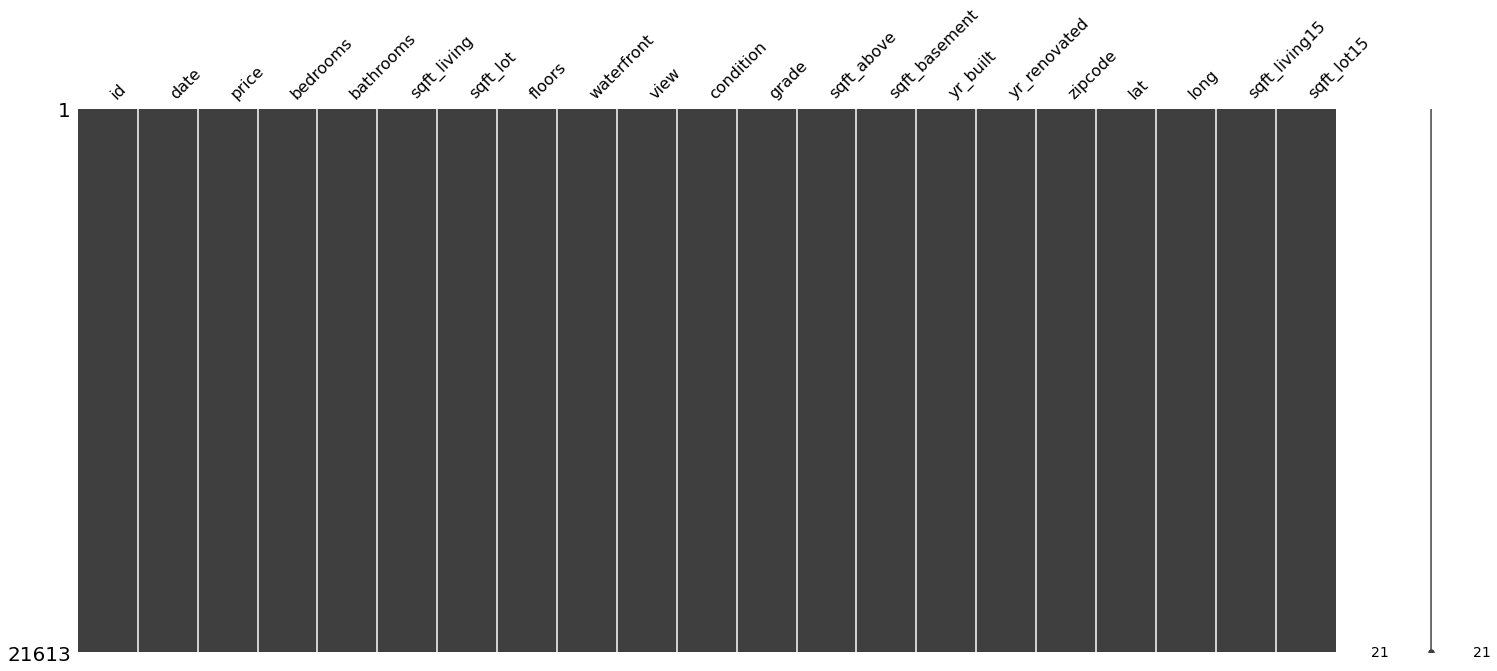

In [ ]:
# Initialization
uniques = []
obj_df = df

# Get data size
size = df.size

# Get datatypes of columns
feature_types = df.dtypes

# Get unique values from data
for (columnName, columnData) in obj_df.iteritems():
    obj_df[columnName] = df[columnName].astype('category')
    obj_df[columnName] = obj_df[columnName].cat.codes
    uniques.append(obj_df[columnName].unique())

# Create unique dataframe and remove NaN values
unique_df = pd.DataFrame(uniques)
unique_df = unique_df.dropna(axis=1)

print("\n\nSize of Data\n", size,
      "\n\nFeature Data Types \n", feature_types,
      "\n\nNull values \n", df.isnull().values, msno.matrix(df),
      "\n\nUnique Category Values", unique_df)

### 3. Correlation [15 points]
- Check the correlation between the features and target values (house' prices) (Provide a bar chart).
- Maybe remove features which do not have much impact on the price (Mention if any).
- Visualise the first three highest correlated features across the (house' prices).

,index,features,correlation_wrt_price
0,8,condition,0.038343
1,13,long,0.061062
2,15,sqft_lot15,0.114515
3,4,sqft_lot,0.125558
4,6,waterfront,0.136044
5,11,sqft_basement,0.295381
6,5,floors,0.307581
7,7,view,0.321629
8,1,bedrooms,0.343043
9,12,lat,0.461054


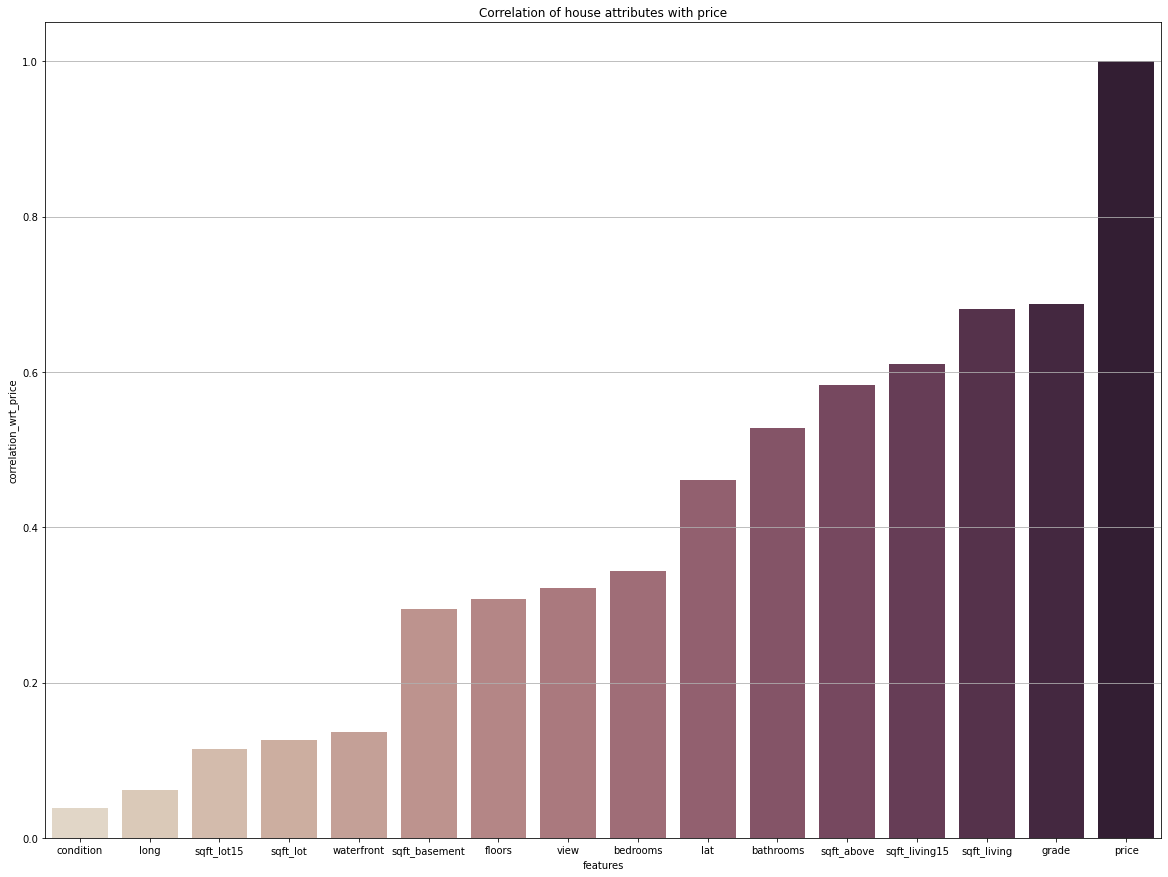

In [ ]:
# Initialization
features = []
feats = pd.DataFrame()

#Find correlation of features wrt price; removed values don't seem to add much to the analysis
new_df = df.drop(['id','date','yr_built','yr_renovated', 'zipcode'], axis = 1)
corr = new_df[new_df.columns].corr()['price'][:]

# Create correlation Dataframe from Series and get price values
corrs = pd.DataFrame(corr)
corrs.dropna(axis=1)
corrs = pd.DataFrame(corrs['price'].values)

# Get features for labeling
for (columnName, columnData) in new_df.iteritems():
    features.append(columnName)
    feats = pd.DataFrame(features)

# Create correlation dataframe for price feature
corr_df = pd.concat([feats, corrs], axis = 1)
corr_df.columns = ['features', 'correlation_wrt_price']

#To visualize top 'x' items
corr_df = corr_df.sort_values(['correlation_wrt_price']).reset_index(drop = False)

# Figure
plt.figure(figsize = (20, 15))
plt.grid()
plt.title('Correlation of house attributes with price')
sns.barplot(x = corr_df['features'], y = corr_df['correlation_wrt_price'], palette = "ch:.25")
corr_df

## Task 2: Ensemble Method [30 points]

###  Apply the methods using sklearn library  

- Split the data into training and testing sets (75-25%)
- Train and test the model for
    - AdaBoost[15 points]
    - Random Forest [15 points]


In [ ]:
#Prepare data for train and test
x = new_df.drop(['price'], axis = 1)
y = new_df['price']

#Encode values for training
labelencoder = LabelEncoder()
x.apply(LabelEncoder().fit_transform)

x.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,lat,long,sqft_living15,sqft_lot15
0,3,3,109,2535,0,0,0,2,5,123,0,2398,223,109,2164
1,3,8,506,3578,2,0,0,2,5,395,56,4478,161,208,3470
2,2,3,39,5520,0,0,0,2,4,40,0,4647,247,491,3804
3,4,11,316,2125,0,0,0,4,5,89,131,2492,87,116,1748
4,3,7,238,4209,0,0,0,2,6,255,0,3439,435,235,3357


In [ ]:
# Split to testing and training sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25)

In [ ]:
# Adaboost classification/ training
abc = AdaBoostClassifier(n_estimators = 50,
                         learning_rate = 1,
                         random_state = 1)

abc_train_start = time.time()

abc_model = abc.fit(x_train, y_train)

abc_train_end = time.time()

In [ ]:
abc_test_start = time.time()

# Adaboost prediction
abc_y_pred = abc_model.predict(x_test)

abc_test_end = time.time()

In [ ]:
# Random forest classification/ training
rf = RandomForestClassifier(n_estimators = 50, criterion = "entropy")

rf_train_start = time.time()

rf_model = rf.fit(x_train, y_train)

rf_train_end = time.time()

In [ ]:
rf_test_start = time.time()

# Random forest prediction
rf_y_pred = rf_model.predict(x_test)

rf_test_end = time.time()

##  Task 3: Evaluate the results [15 points]

- Print the following for both adaboost and random forest [10 points]
    - Variance score (test)
    - R2 score (test)
    - Time taken (train)(test)
    - max error (test)
    - mean absolute error (test)
  
- Which performed well adaboost or random forest? why?[5 points]


In [ ]:
#Compute train and test time for AdaBoost
abc_train_time = (abc_train_end - abc_train_start)
abc_test_time = (abc_test_end - abc_test_start)

In [ ]:
print("AdaBoost results\n\n",
      "Variance Score (test): ", explained_variance_score(y_test, abc_y_pred),
      "\n R2 Score (test): ", r2_score(y_test, abc_y_pred),
      "\n Time taken to train: ", abc_train_time, "s",
     "\n Time taken to test: ", abc_test_time, "s",
     "\n Max Error (test): ", max(abc_model.estimator_errors_),
     "\n Mean Absolute Error (test): ", mean_absolute_error(y_test, abc_y_pred))

AdaBoost results

 Variance Score (test):  0.3235075301179102 
 R2 Score (test):  0.9990469790770634 
 Time taken to train:  81.20282697677612 s 
 Time taken to test:  20.85845112800598 s 
 Max Error (test):  0.9994140052739525 
 Mean Absolute Error (test):  755.5085122131754


In [ ]:
#Compute train and test time for Random Forest
rf_train_time = (rf_train_end - rf_train_start)
rf_test_time = (rf_test_end - rf_test_start)

In [ ]:
print("Random Forest results\n\n",
      "Variance Score (test): ", explained_variance_score(y_test, rf_y_pred),
      "\n R2 Score (test): ", r2_score(y_test, rf_y_pred),
      "\n Time taken to train: ", rf_train_time, "s",
      "\n Time taken to test: ", rf_test_time, "s",
      "\n Max Error (test): ", max_error(y_test, rf_y_pred),
      "\n Mean Absolute Error (test): ", mean_absolute_error(y_test, rf_y_pred))

Random Forest results

 Variance Score (test):  0.7383839440276241 
 R2 Score (test):  0.9975117044791982 
 Time taken to train:  95.04680395126343 s 
 Time taken to test:  11.224459171295166 s 
 Max Error (test):  2839 
 Mean Absolute Error (test):  366.37453737971873


Adaboost was faster to train, but Random forest was faster to test.
<br>
In terms of max error i used different metrics; for adaboost a ratio, and for random forest a count. 0.99 doesn't seem well for performance. (using the count value i got 3505 so it's still not good)
<br>
As for mean absolute error, random forest seems to have a lower mean, with high variance so we can't safely say that it has a lower interval of errors.
<br>
Random forest seems to perform slightly better than Adaboost. However, both models need to be optimized for a better result when it comes to accuracy and performance overall. Perhaps the data is highly dimensional. Maybe we need to increase the dataset size as well.

## Task 4: Complexity curve [20 points]
- Plot the complexity curve for Variance score for 50 tree number [Refer lecture slide 9]
    - Adaboost for test and train [10 points]
    - Random forest for test and train [10 points]
    
Note:- This may take a lot of time and RAM kindly do it in google Colab if the laptop doesn't have GPU

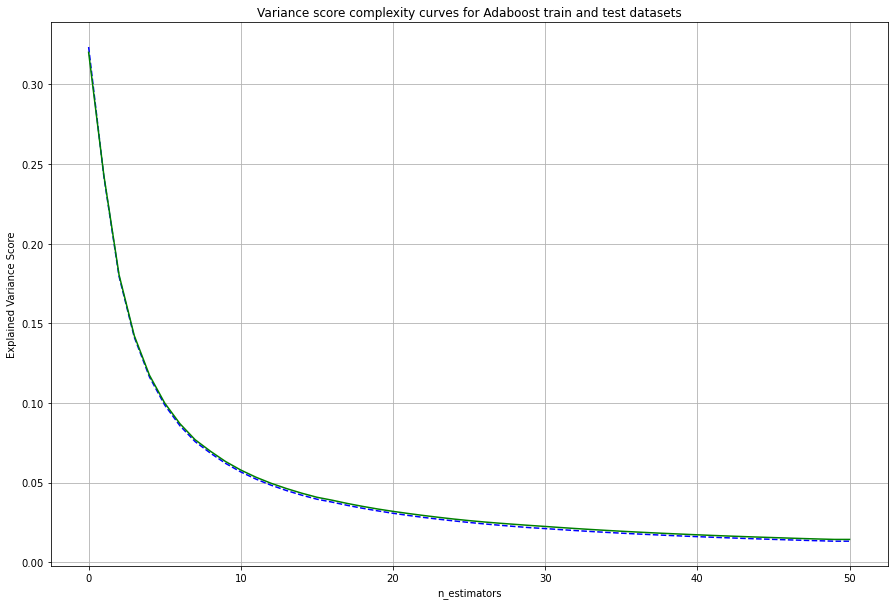

In [ ]:
plt.figure(figsize=(15,10))
plt.grid()
plt.xlabel("n_estimators")
plt.ylabel("Explained Variance Score")
plt.title("Variance score complexity curves for Adaboost train and test datasets")

#Complexity curve for variance score of Adaboost test and train datasets
abc_test_preds = np.stack([abc_model.predict(x_test) for abc_model in abc.estimators_])
abc_test_preds[:,0], np.mean(abc_test_preds[:,0])
plt.plot([explained_variance_score(y_test, np.mean(abc_test_preds[:i+1], axis=0)) for i in range(51)], color = "blue", label = 'Adaboost test', linestyle = '--')

abc_train_preds = np.stack([abc_model.predict(x_train) for abc_model in abc.estimators_])
abc_train_preds[:,0], np.mean(abc_train_preds[:,0])
plt.plot([explained_variance_score(y_train, np.mean(abc_train_preds[:i+1], axis=0)) for i in range(51)], color = "green", label = 'Adaboost train')

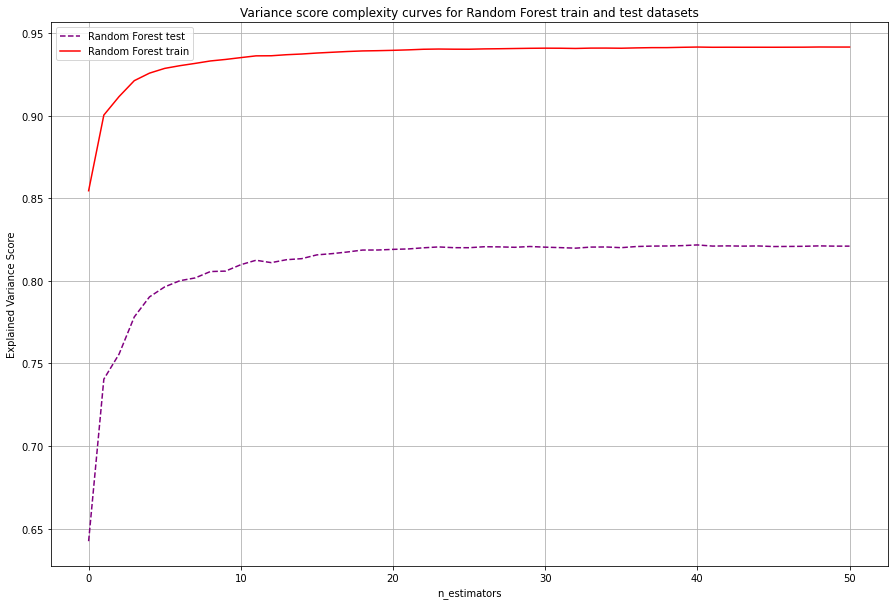

In [ ]:
plt.figure(figsize=(15,10))
plt.grid()
plt.xlabel("n_estimators")
plt.ylabel("Explained Variance Score")
plt.title("Variance score complexity curves for Random Forest train and test datasets")

#Complexity curve for variance score of Random Forest test and train datasets
rf_test_preds = np.stack([rf_model.predict(x_test) for rf_model in rf.estimators_])
rf_test_preds[:,0], np.mean(rf_test_preds[:,0])
plt.plot([explained_variance_score(y_test, np.mean(rf_test_preds[:i+1], axis=0)) for i in range(51)], color = "purple", label = 'Random Forest test', linestyle = '--')

rf_train_preds = np.stack([rf_model.predict(x_train) for rf_model in rf.estimators_])
rf_train_preds[:,0], np.mean(rf_train_preds[:,0])
plt.plot([explained_variance_score(y_train, np.mean(rf_train_preds[:i+1], axis=0)) for i in range(51)], color = "red", label = 'Random Forest train')

plt.legend(loc='best')

We conclude that adaboost variance decreases wheras that of random forest increases but then becomes stable. Train and test datasets show somewhat similar outputs for variance score. In random forest, variance increases with n_estimators but then becomes stable.